# Basic principles of AJX

This notebook demonstrates how to instantiate a pre-built AJX environment, evolve it over time, and use Jax compositions such as `jax.jacfwd`, `jax.vmap`, and `jax.grad`.

The underlying AJX simulation object is wrapped inside the environment, so it is not directly exposed in the code below. A future notebook will show how to build a simulation from scratch.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

rotary_encoder.x: -0.6331520080566406


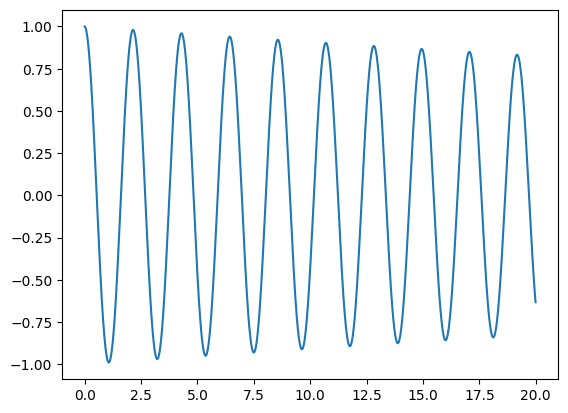

In [2]:
from ajx.example_environments import Pendulum
from ajx.simulation import SimulationSettings
import matplotlib.pyplot as plt
import numpy as np
 
# Create the pendulum environment
env = Pendulum(SimulationSettings(timestep=0.01), has_quadratic_damping=False)

# Use the default parameters
env_param = env.default_param.tree_replace({})

# Get the initial state by specifying in angle
state = env.state_from_angle(1.0, env_param)

# Allocate an array to store the observations over time
observation_array = np.zeros([2000])

# Simulation loop
for i in range(2000):
    # Step the environment and store the observation
    state, observations = env.step(state, None, env_param)
    observation_array[i] = observations[0]
plt.plot(np.arange(2000)*env.sim.settings.timestep, observation_array)
print("\t".join(env.observation_strings(observations)))


## Parallel Simulation Example
Below are examples of how AJX simulations can be stepped in parallel. For an ensemble of simulations that share the same constraint graph, `jax.vmap` can be used to run them in parallel. This is always the case for ensambles of the same AJX environment (since geometry, collisions, and inequality constraints are not supported).

For heterogeneous ensembles, or for simulations involving contact, the recommended approach is to pass all data to the solver as a single simulation rather than using `jax.vmap`. However, the current AJX solvers are not well-suited for this approach yet.

Text(0, 0.5, 'Angle (rad)')

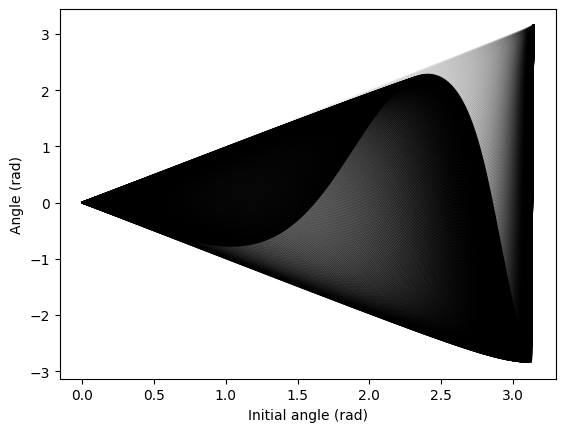

In [3]:
# Example with different initial conditions
import jax.numpy as jnp
from jax import vmap

# Create an array of initial angles 
initial_angles = jnp.linspace(0, jnp.pi, 200)

# Use vmap to get an ensemble of initial states
states = vmap(env.state_from_angle, in_axes=(0, None))(initial_angles, env_param)

for i in range(300):
    # Use vmap to step the ensemble
    states, observations = vmap(env.step, in_axes=(0, None, None))(
        states, None, env_param
    )
    # Plot the angles versus initial angles
    plt.plot(initial_angles, observations.flatten(), color=(0, 0, 0, i / 300))

plt.xlabel("Initial angle (rad)")
plt.ylabel("Angle (rad)")

## AJX Parameter Node indexing

In [4]:
from ajx import RigidBodyParameters

# Option 1
body1_param = RigidBodyParameters.create(1.0, [0.4, 0.5, 0.6], "body1")
body2_param = RigidBodyParameters.create(2.0, [0.7, 0.8, 0.9], "body2")
rb_param = RigidBodyParameters.concatenate([body1_param, body2_param])

# Option 2
rb_param = RigidBodyParameters(
    ("body1", "body2"),
    mass=jnp.array([1.0, 2.0]),
    mc=jnp.zeros([2,3]),
    inertia=jnp.array([[0.4, 0., 0., 0.5, 0., 0.6], [0.7, 0., 0., 0.8, 0., 0.9]]),
)

# Getting parameter values
mass = rb_param.get_value_at_path("mass.body1")
print(f"Mass is {mass}")

# Overwriting parameter values
rb_param2 = rb_param.tree_replace({"mass.body1": 3.0, "inertia.body1.xx": 1.0})
new_mass = rb_param2.get_value_at_path("mass.body1")
new_inertia = rb_param2.get_value_at_path("inertia.body1")
print(f"Updates mass is {new_mass}")
print(f"Updates inertia is {new_inertia}")

Mass is 1.0
Updates mass is 3.0
Updates inertia is [1.  0.  0.  0.5 0.  0.6]


With the help of clever parameter indexing and vmap, it is possible to simulate an ensamble with different parameter values.

Text(0, 0.5, 'Angle (rad)')

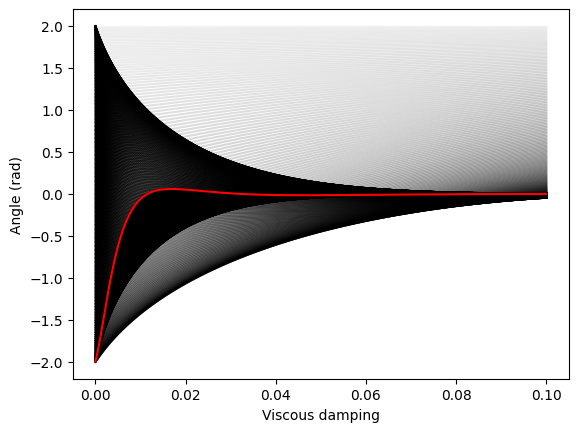

In [5]:
# Example with different simulation parameters
n_simulations = 200

# Create parameter array
damping_ensemble = jnp.linspace(1e-5, 1e-1, n_simulations)
holonomic_compliance_ensemble = jnp.repeat(
    1e-5 * jnp.ones([n_simulations])[:, None, None], 5, axis=2
)
full_compliance_ensemble = jnp.concatenate(
    [holonomic_compliance_ensemble, 1 / damping_ensemble[:, None, None]], axis=2
)
# Create a new SimulationParameters object with a compliance array that has an extra dimension
env_param = env.default_param.tree_replace(
    {
        "constraint_param.compliance":  full_compliance_ensemble,
    }
)
# Use the same initial angle for all simulations
initial_angles = jnp.ones([n_simulations]) * 2.0
states = vmap(env.state_from_angle, in_axes=(0, None))(initial_angles, env_param)

# Create in_axis object that specifies what key to map over (broken)
in_axes_simulation_param = env_param.create_in_axes(
    {"constraint_param": env_param.constraint_param.create_in_axes({"compliance": 0})}
)

for i in range(400):
    states, observations = vmap(env.step, in_axes=(0, None, in_axes_simulation_param))(
        states, None, env_param
    )
    # Plot the angles versus damping
    plt.plot(damping_ensemble, observations.flatten(), color=(0, 0, 0, i / 400))

plt.plot(damping_ensemble, observations.flatten(), color=(1, 0, 0, 1.0))

plt.xlabel("Viscous damping")
plt.ylabel("Angle (rad)")


# JAX derivatives
Below are examples of how to take derivatives in jax using `jax.grad` and `jax.jacfwd`. 

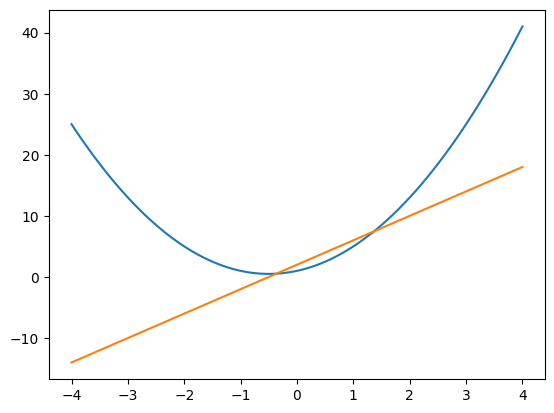

In [6]:
# Basic example of grad
from jax import grad, vmap
def foo(x):
    return 2*x**2 + 2*x +1

x = jnp.linspace(-4, 4, 100)
y = foo(x)
foo_prime = grad(foo)

# vmap is needed since grad requires a scalar output
y_prime = vmap(foo_prime)(x)
plt.plot(x, y)
plt.plot(x, y_prime)

In the next block we use Newton's method and `jax.jacfwd` to solve the following nonlinear system of equations
$$
x_1^2 + x_2 - 1 = 0 \\
x_1 + x_2^2 - 1 = 0.
$$

In [7]:
import jax

def f(x):
    return jnp.array([
        x[0]**2 + x[1] - 1.0,
        x[0] + x[1]**2 - 1.0
    ])

jac_f = jax.jacfwd(f)

def newton(x0, max_iter=10):
    x = x0
    for _ in range(max_iter):
        J = jac_f(x)
        fx = f(x)
        # Solve J * delta = f(x)
        delta = -jnp.linalg.solve(J, fx)
        x = x + delta
    return x

# Initial guess
x0 = jnp.array([0.2, 0.8])

solution = newton(x0)
print("Solution:", solution)
print("f(solution):", f(solution))


Solution: [-1.6301783e-08  1.0000000e+00]
f(solution): [0. 0.]


# AJX derivatives
In AJX, it is recommended to compute derivatives in **tangent spaces** rather than assuming all variables lie in Euclidean space $\mathbb{R}^n$. This is important because many objects (e.g., rotations, transforms, spatial inertia) have geometric structure better described as **manifolds**, not flat vector spaces. This approach also allows restricting the tangent space by **meta-attributes in the parameter object itself**, enabling very convenient computation of Jacobians with respect to parameter subsets.

We recommended using the **hierarchical parameter node system** provided in AJX. All AJX parameter structures (including states) inherits from the class `ParameterNode`, making them **parameter nodes**. Parameter nodes expose a `retract` function which increments the structure by a vector in the tangent space. The `retract` method can be seen as a generalization of addition. 

Mathematically, a `ParameterNode` represents a point $x \in \mathcal{M}$
$$
x_{\text{new}} = \mathrm{Retract}(x, \delta).
$$
The corresponding Python code is
```python
x_new = x.retract(delta)
```
Below is a demonstration of the `retract` method applied to a `Transform`.

In [ ]:
# Create a transform
from ajx.definitions import Transform
import ajx.math as math
transform = Transform(
    pos=jnp.array([0.0, 0.0, 0.0]),
    rot=jnp.array([1.0, 0.0, 0.0, 0.0]),
)

print(transform.tangent_size())
# The size of the tangent vector has to match the transform.tangent_size()
new_transform = transform.retract(jnp.array([1.0, 2.0, 3.0, 0.0, 0.0, 0.3]))
print(f"pos: {new_transform.pos}")
axis, angle = math.to_axis_angle(new_transform.rot)
print(f"axis: {axis}\tangle: {angle}")

6
pos: [1. 2. 3.]
axis: [0. 0. 1.]	angle: 0.30000001192092896


## Tangent Space Derivatives
For a function
$
f : \mathcal{M} \rightarrow \mathbb{R},
$
the (directional) derivative at $x \in \mathcal{M}$ is defined by perturbing in the tangent space:
$$
\frac{d}{d\epsilon} f(\mathrm{Retract}(x, \epsilon \,\delta)) \Big|_{\epsilon=0}, \quad \delta \in T_x\mathcal{M}.
$$
The tangent space Jacobian is computed as:
$$
J(x) = \frac{\partial}{\partial \delta} f(\mathrm{Retract}(x, \delta)) \Big|_{\delta=0}
$$
These definitions ensure derivatives respect the geometry of the underlying manifold. It also avoids flattening complex structures—only the tangent vector $\delta$ needs to be a 1D representation.

In the next block we use Newton's method and `ajx.tangent_jacfwd` to find a transform that satisfies some criteria.

In [9]:
from ajx.tree_util import tangent_jacfwd

# For now, the criteria is just to have zero distance to a target transform
target_transform = new_transform
def f(transform_a: Transform):
    pos_delta = transform_a.pos - target_transform.pos
    rot_delta = math.quat_residual(transform_a.rot, target_transform.rot)
    return jnp.concatenate([pos_delta, rot_delta])

jac_f = tangent_jacfwd(f)

def newton(x0, max_iter=10):
    x = x0
    for _ in range(max_iter):
        J = jac_f(x)
        fx = f(x)
        # Solve J * delta = f(x)
        delta = -jnp.linalg.solve(J, fx)
        x = x.retract(delta)
    return x

# Initial guess
x0 = Transform(
    pos=jnp.array([0.0, 0.0, 0.0]),
    rot=jnp.array([1.0, 0.0, 0.0, 0.0]),
)

solution = newton(x0)
print(f"solution.pos: {solution.pos}")
axis, angle = math.to_axis_angle(solution.rot)
print(f"solution.axis: {axis}\tsolution.angle: {angle}")


solution.pos: [1. 2. 3.]
solution.axis: [0. 0. 1.]	solution.angle: 0.30000001192092896


## Parameter sensitivity example

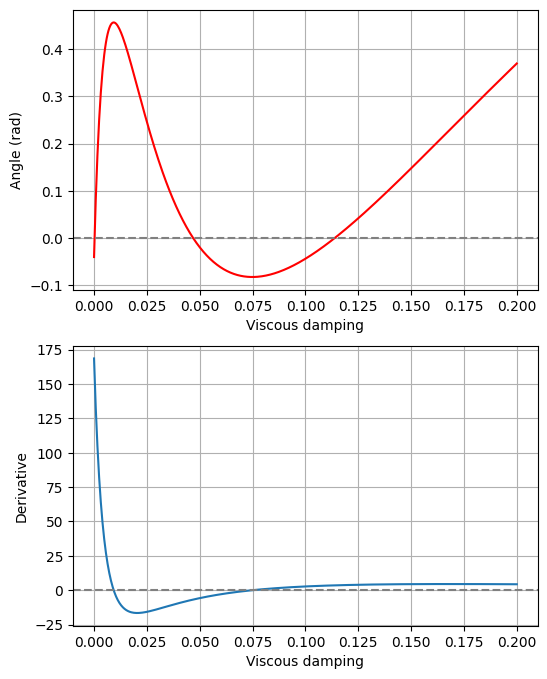

In [10]:
import jax.lax as lax
from jax import vmap

env_param = env.default_param

# Example with different simulation parameters
n_simulations = 500

# Create parameter array
damping_ensemble = jnp.linspace(1e-5, 0.2, n_simulations)

# Use the same initial angle for all simulations
initial_angle = 2.0
state = env.state_from_angle(initial_angle, env.default_param)


def simulate(damping, state):
    env_param = env.default_param.tree_replace(
        {
            "constraint_param.compliance.hinge.5": (1 / damping),
        }
    )

    def body_fn(i, carry):
        state = carry
        state, _ = env.step(state, None, env_param)
        return state

    state = lax.fori_loop(0, 200, body_fn, state)

    _, observation = env.step(state, None, env_param)
    return observation[0]


observations = vmap(simulate, in_axes=(0, None))(damping_ensemble, state)
grad_func = jax.grad(simulate, argnums=0)
observation_jac = vmap(grad_func, in_axes=(0, None))(damping_ensemble, state)

fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 8))

# Top plot: observations
ax1.plot(damping_ensemble, observations.flatten(), color=(1, 0, 0, 1.0))
ax1.set_ylabel("Angle (rad)")
ax1.set_xlabel("Viscous damping")
ax1.axhline(0, color='gray', linestyle='--')
ax1.grid(True)

# Bottom plot: derivative
ax2.plot(damping_ensemble, observation_jac)
ax2.set_ylabel("Derivative")
ax2.set_xlabel("Viscous damping")
ax2.axhline(0, color='gray', linestyle='--')
ax2.grid(True)


## Finding a stationary starting configuration

2026-03-17 17:29:33.529 | WARNING  | ajx.tree_util:tree_replace:169 - Using a fix that may cause problems(?)


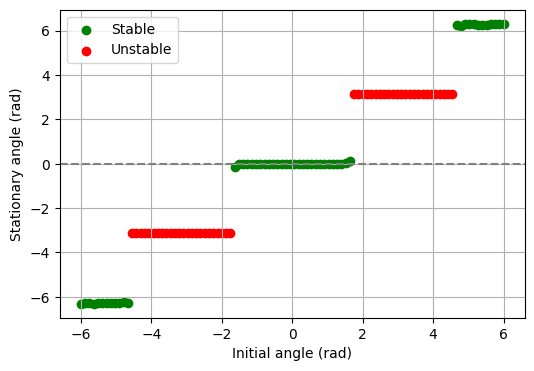

In [11]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State

# For now, the criteria is just to have zero distance to a target transform
def residual(state: State):
    new_state, _ = env.step(state, None, env_param)
    return new_state.gvel.data.flatten()


jac_r = tangent_jacfwd(residual)


def gauss_newton(x0, max_iter, damping):
    x = x0
    for _ in range(max_iter):
        J = jac_r(x)  # shape (m, n)
        rx = residual(x)  # shape (m,)

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)

        x = x.retract(delta)
    return x, J


# Initial guesses
theta0s = jnp.linspace(-6.0, 6.0, 100)
x0s = vmap(env.state_from_angle, in_axes=(0, None))(theta0s, env_param)

# We restrict the search to configuration. Velocity is not included in the search.
x0s = x0s.replace(tangent_restrictions=("conf",))

solutions, Js = vmap(gauss_newton, in_axes=(0, None, None))(x0s, 6, 1e-3)
eigvals = jnp.real(vmap(jnp.linalg.eigvals)(Js))
stable = jnp.all(eigvals < 0, axis=1)
observations = vmap(env.observe_state, in_axes=(0, None, None))(
    solutions, None, env_param
)
obs =  observations.flatten()
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.axhline(0, color='gray', linestyle='--')
ax1.grid(True)

# Stable points
ax1.scatter(
    theta0s[stable],
    obs[stable],
    color="green",
    label="Stable"
)

# Unstable points
ax1.scatter(
    theta0s[~stable],
    obs[~stable],
    color="red",
    label="Unstable"
)
ax1.set_ylabel("Stationary angle (rad)")
ax1.set_xlabel("Initial angle (rad)")
ax1.legend()